In [1]:
from obspy.clients.fdsn.header import URL_MAPPINGS
print(URL_MAPPINGS.keys())

dict_keys(['AUSPASS', 'BGR', 'EIDA', 'ETH', 'EMSC', 'GEONET', 'GEOFON', 'GFZ', 'ICGC', 'IESDMC', 'INGV', 'IPGP', 'IRIS', 'IRISPH5', 'ISC', 'KNMI', 'KOERI', 'LMU', 'NCEDC', 'NIEP', 'NOA', 'ODC', 'ORFEUS', 'RESIF', 'RESIFPH5', 'RASPISHAKE', 'SCEDC', 'TEXNET', 'UIB-NORSAR', 'USGS', 'USP'])


https://www.fdsn.org/networks/

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

# 1. Initialize the client
# We connect to INGV, the source of the INSTANCE dataset
client = Client("IRIS")

# Define your station parameters
DATA_CENTER = "IRIS"
STATION_CODE = "GO01"
LATITUDE = -19.6685
LONGITUDE = -69.1942

# 2. Define your time interval
starttime = UTCDateTime("2020-06-01T00:00:00")
endtime = UTCDateTime("2020-06-03T00:00:00")

In [3]:
# First, let's check what stations and channels are available
print("Checking available stations...")

try:
    inventory = client.get_stations(
        network="C",
        station=STATION_CODE,
        starttime=starttime,
        endtime=endtime,
        level="channel"  # Get detailed channel information
    )
    
    print("\nAvailable stations and channels:")
    print(inventory)
    
except Exception as e:
    print(f"Error fetching station info: {e}")

Checking available stations...

Available stations and channels:
Inventory created at 2025-11-17T23:04:30.182500Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2020-06-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			C
		Stations (1):
			C.GO01 (Chusmiza, Chile)
		Channels (57):
			C.GO01..ACE, C.GO01..BHZ, C.GO01..BHN, C.GO01..BHE, C.GO01..HNZ, 
			C.GO01..HNN, C.GO01..HNE, C.GO01..LCE, C.GO01..LCQ, C.GO01..LHZ, 
			C.GO01..LHN, C.GO01..LHE, C.GO01..LNZ, C.GO01..LNN, C.GO01..LNE, 
			C.GO01..LOG, C.GO01..OCF, C.GO01..UHZ, C.GO01..UHN, C.GO01..UHE, 
			C.GO01..VCO, C.GO01..VEA, C.GO01..VEC, C.GO01..VEP, C.GO01..VHZ, 
			C.GO01..VHN, C.GO01..VHE, C.GO01..VKI, C.GO01..VM0, C.GO01..VM1, 
			C.GO01..VM2, C.GO01..VM3, C.GO01..VM4, C.GO01..VM5, C.GO01..VM6, 
			C.GO01..VPB, C.GO01.EP.BDF, C.GO01.EP.BDO, C.GO01.EP.LCE, 
			C.GO01.EP.LCO, C.GO01.EP.LDF, C.GO01.EP.LDM, C.GO01.EP.LDO, 
			

Channel Codes:

BHZ: Vertical component (up and down motion).

BHN: North-South horizontal component (motion along the north-south line).

BHE: East-West horizontal component (motion along the east-west line). 

Fetching waveform data...
Data downloaded successfully!
1 Trace(s) in Stream:
C.GO01..BHZ | 2020-06-01T00:00:00.024998Z - 2020-06-02T23:59:59.999998Z | 40.0 Hz, 6912000 samples


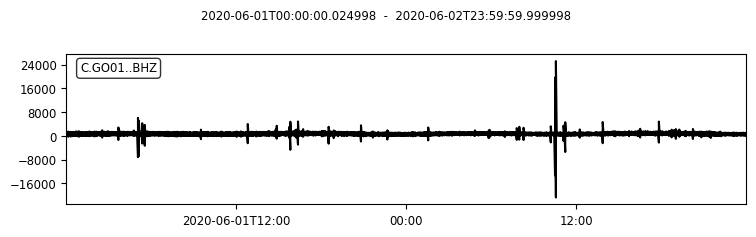

In [4]:
print("Fetching waveform data...")

# 4. Request the data
# Station GO01 has BH* (broadband high gain) channels, not HH* channels
try:
    st = client.get_waveforms(
        network="C",  # C: Chilean National Seismic Network
        station=STATION_CODE,
        location="*",  # Get all locations
        channel="BHZ",  # Broadband channels (BHZ, BHN, BHE) - commonly used for seismic analysis
        starttime=starttime,
        endtime=endtime
    )

    print("Data downloaded successfully!")
    print(st)
    
    # You can now save this small stream or process it
    st.plot()

except Exception as e:
    print(f"No data found or request failed: {e}")

In [5]:
# Check how many traces (time series) are in the stream
print(f"Number of traces in stream: {len(st)}")
print("\nDetails of each trace:")
for i, trace in enumerate(st):
    print(f"{i+1}. {trace.stats.channel}: {trace.stats.network}.{trace.stats.station}.{trace.stats.location}.{trace.stats.channel}")
    print(f"   Samples: {trace.stats.npts}, Sampling rate: {trace.stats.sampling_rate} Hz")
    print(f"   Start: {trace.stats.starttime}, End: {trace.stats.endtime}")

Number of traces in stream: 1

Details of each trace:
1. BHZ: C.GO01..BHZ
   Samples: 6912000, Sampling rate: 40.0 Hz
   Start: 2020-06-01T00:00:00.024998Z, End: 2020-06-02T23:59:59.999998Z


In [6]:
# Get the BHZ trace (vertical component)
bhz_trace = st.select(channel='BHZ')[0]

# Number of points in the trace
npts = bhz_trace.stats.npts
# Sampling rate
sampling_rate = bhz_trace.stats.sampling_rate
# Start time
start_time = bhz_trace.stats.starttime

# Get the data as a NumPy array
bhz_data = bhz_trace.data
bhz_data

array([430, 437, 458, ..., 671, 688, 686])

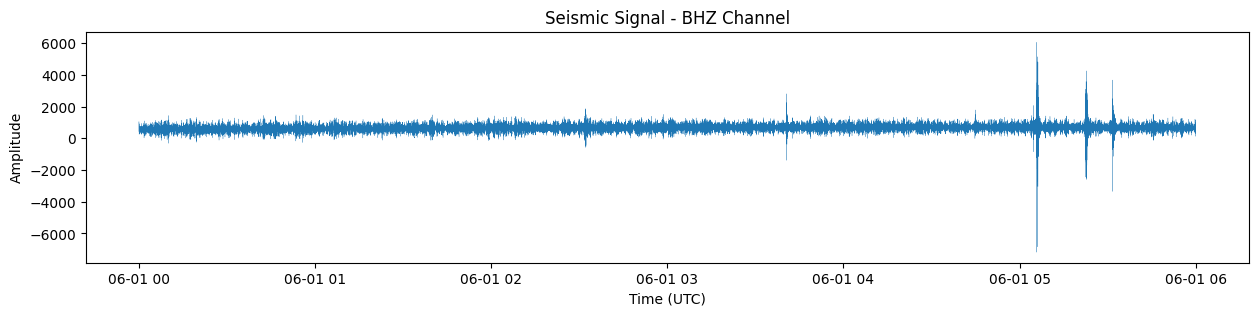

In [7]:
sample = npts // 8  # Take first 1/16th of the data for plotting

ts = [start_time + i / sampling_rate for i in range(sample)]
ts = [t.datetime for t in ts]  # Convert to datetime for better plotting

plt.figure(figsize=(15, 3))
plt.plot(ts, bhz_data[:sample], linewidth=0.2)
plt.xlabel("Time (UTC)")
plt.ylabel("Amplitude")
plt.title("Seismic Signal - BHZ Channel")
plt.show()

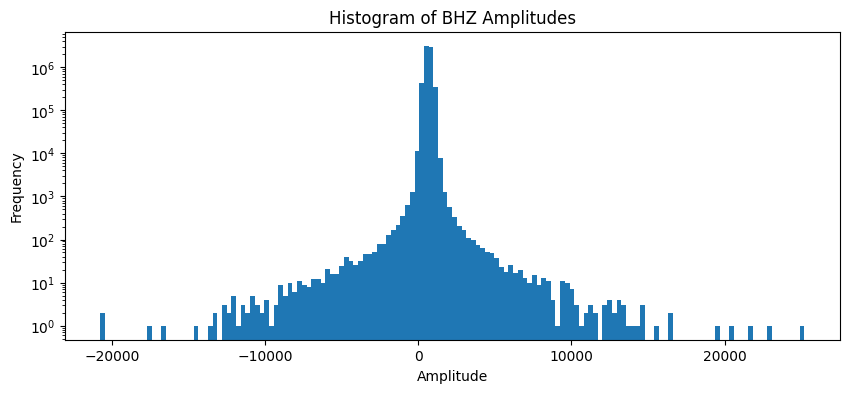

In [8]:
# Plot histogram of amplitudes

plt.figure(figsize=(10, 4))
plt.hist(bhz_data, bins=150)
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.title("Histogram of BHZ Amplitudes")
plt.yscale('log')
plt.show()

In [9]:
st.write('seismic_data.mseed', format='MSEED')

In [10]:
from obspy import read

# Load the MiniSEED file
st_loaded = read('seismic_data.mseed')

print("Loaded stream:")
print(st_loaded)

# Access the data as before
bhz_trace_loaded = st_loaded.select(channel='BHZ')[0]
bhz_data_loaded = bhz_trace_loaded.data

print(f"Data shape: {bhz_data_loaded.shape}")
print(f"First 10 samples: {bhz_data_loaded[:10]}")

Loaded stream:
1 Trace(s) in Stream:
C.GO01..BHZ | 2020-06-01T00:00:00.024998Z - 2020-06-02T23:59:59.999998Z | 40.0 Hz, 6912000 samples
Data shape: (6912000,)
First 10 samples: [430 437 458 460 467 485 493 494 508 523]


Get events

In [11]:
from obspy.clients.fdsn import Client

# Initialize client for event catalog (USGS is commonly used)
event_client = Client("IRIS")

# Search for events in the same time window
print("Searching for earthquake events...")

starttime = UTCDateTime("2025-01-01T00:00:00")
endtime = UTCDateTime("2025-06-10T00:00:00")

window = 5

try:
    catalog = event_client.get_events(
        starttime=starttime,
        endtime=endtime,
        minlatitude=LATITUDE - window,  # Search within ~500km radius
        maxlatitude=LATITUDE + window,
        minlongitude=LONGITUDE - window,
        maxlongitude=LONGITUDE + window,
        minmagnitude=4.0  # Minimum magnitude to avoid too many small events
    )
    
    print(f"\nFound {len(catalog)} events")
    print(catalog)
        
except Exception as e:
    print(f"Error fetching events: {e}")

Searching for earthquake events...

Found 248 events
248 Event(s) in Catalog:
2025-06-08T02:28:06.243000Z | -22.681,  -66.635 | 4.2  mb
2025-06-07T14:01:36.101000Z | -21.068,  -68.940 | 4.7  mb
...
2025-01-01T08:08:31.981000Z | -22.590,  -68.934 | 4.1  mb
2025-01-01T03:56:39.832000Z | -23.029,  -66.608 | 4.9  Mww
To see all events call 'print(CatalogObject.__str__(print_all=True))'


In [12]:
from obspy.geodetics import locations2degrees

# Use the predefined station coordinates
sta_lat = LATITUDE
sta_lon = LONGITUDE

filtered_catalog = []
max_distance_km = 150
# Convert km to degrees (approx. 111.19 km per degree)
max_distance_degrees = max_distance_km / 111.19

for event in catalog:
    origin = event.preferred_origin() or event.origins[0]
    eq_lat = origin.latitude
    eq_lon = origin.longitude

    # Calculate distance
    distance_degrees = locations2degrees(eq_lat, eq_lon, sta_lat, sta_lon)

    # Check if the event is within the desired distance range
    if distance_degrees <= max_distance_degrees:
        filtered_catalog.append(event)

print(f"Events after filtering by distance/availability: {len(filtered_catalog)}")

Events after filtering by distance/availability: 39


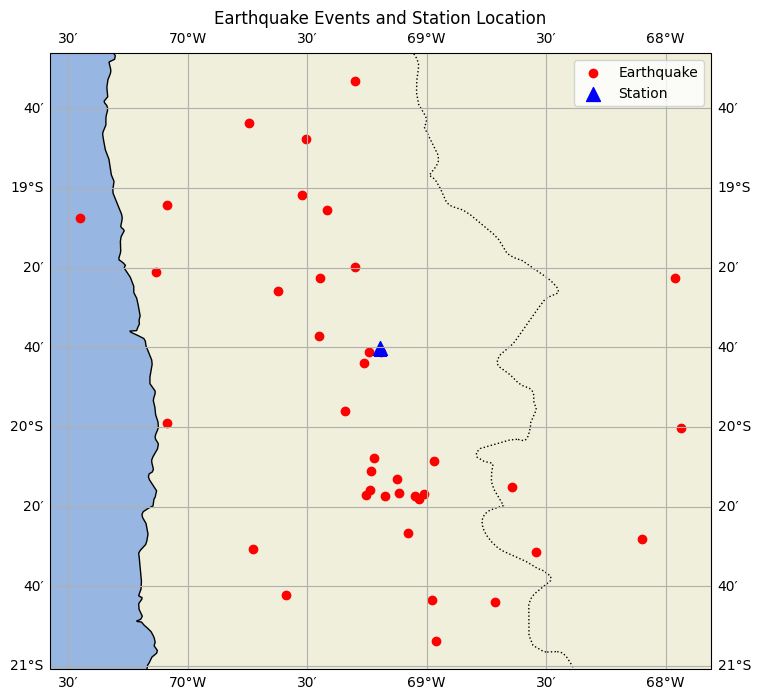

In [13]:
## Scatter plot of event locations and countries contours
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

eq_lats = []
eq_lons = []
for event in filtered_catalog:
    origin = event.preferred_origin() or event.origins[0]
    eq_lats.append(origin.latitude)
    eq_lons.append(origin.longitude)

# Create a figure and a GeoAxes object with a projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

# Plot data points
# Use transform=ccrs.PlateCarree() to specify that the coordinates are in lat/lon
ax.scatter(eq_lons, eq_lats, c='red', marker='o', transform=ccrs.PlateCarree(), label='Earthquake')
ax.scatter([sta_lon], [sta_lat], c='blue', marker='^', s=100, transform=ccrs.PlateCarree(), label='Station')

# Set labels, title, and legend
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.set_title('Earthquake Events and Station Location')

# Add gridlines for better readability
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.show()

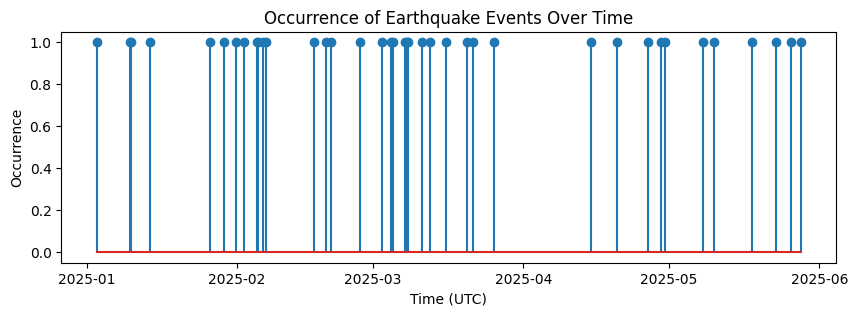

In [14]:
# Ocurrence in the time plt.stem()
event_times = []
for event in filtered_catalog:
    origin = event.preferred_origin() or event.origins[0]
    event_times.append(origin.time.datetime)

plt.figure(figsize=(10, 3))
plt.stem(event_times, np.ones(len(event_times)))
plt.xlabel("Time (UTC)")
plt.ylabel("Occurrence")
plt.title("Occurrence of Earthquake Events Over Time")
plt.show()

In [15]:
from obspy.core.event import Catalog

# Create a new Catalog object with the filtered events
filtered_catalog_obj = Catalog(events=filtered_catalog)

# Save to QuakeML format
filtered_catalog_obj.write('filtered_events.xml', format='QUAKEML')